## Importing Libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,roc_curve,roc_auc_score,precision_score,recall_score,classification_report

## Dataset Loading

In [47]:
df=pd.read_csv("train_csv.csv")

In [48]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## data understanding

In [49]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [50]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [52]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [53]:
df.shape

(614, 13)

## data preprocessing

In [54]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [55]:
df.drop("Loan_ID",axis=1,inplace=True)

In [56]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [57]:
for column in df.columns:
    df[column]=df[column].fillna(df[column].mode()[0])

In [58]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [59]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## Encoding

In [60]:
le = LabelEncoder()
for column in df.select_dtypes(include="object").columns:
    df[column]=le.fit_transform(df[column])
  

In [61]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,120.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## separating input and output


In [62]:
X=df.drop("Loan_Status",axis=1)
y=df["Loan_Status"]

In [63]:
print(X.shape)

(614, 11)


In [64]:
print(y.shape)

(614,)


## Exploratory Data Analysis

## Target Variable distribution

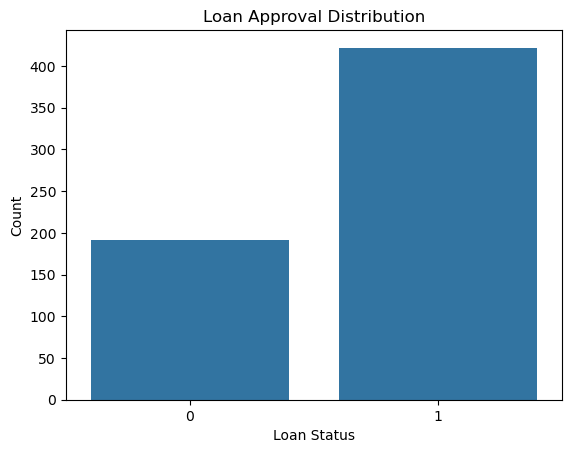

In [65]:
sns.countplot(x="Loan_Status", data=df)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

## Numerical Feature Distribution

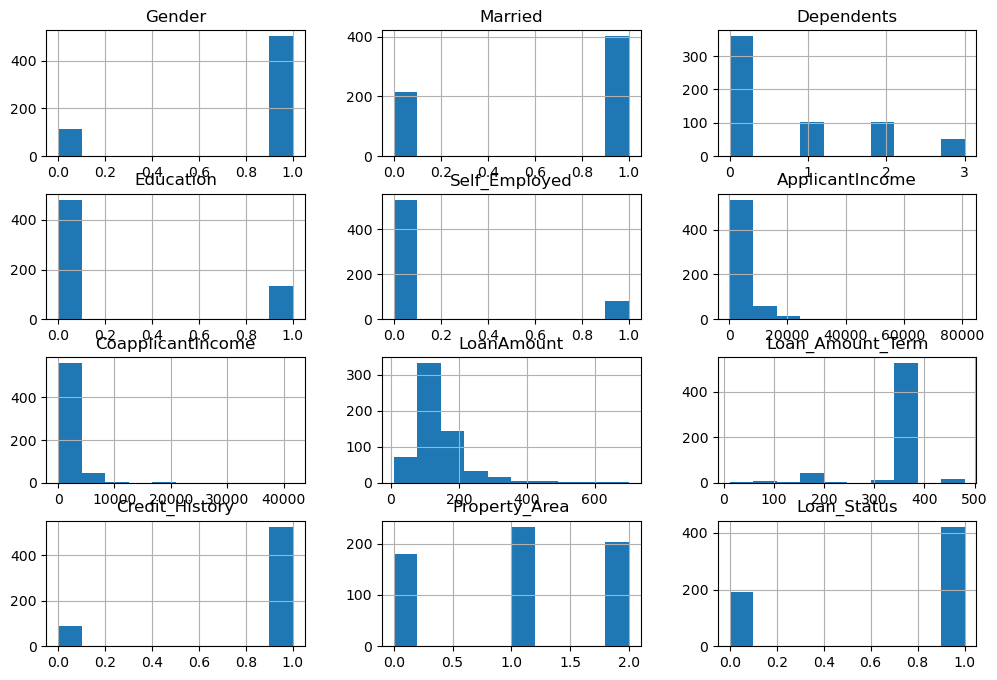

In [66]:
df.hist(figsize=(12,8))
plt.show()

## Boxplot for Outlier Detection

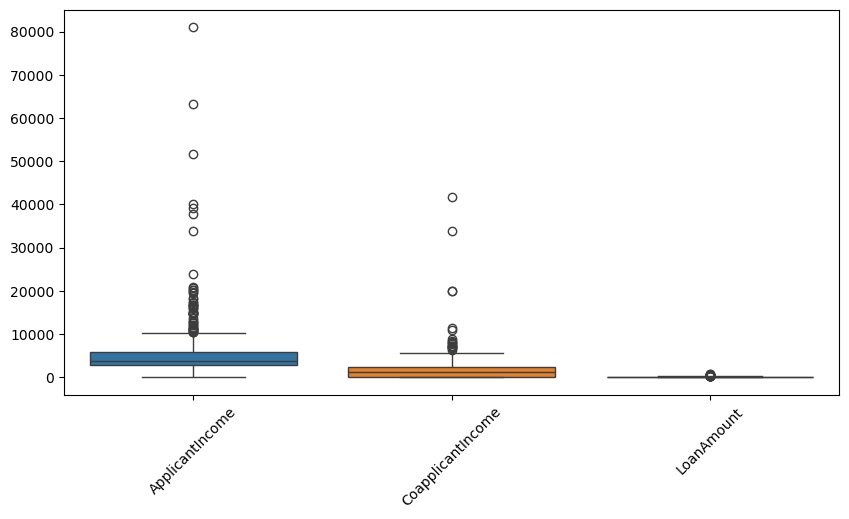

In [67]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['ApplicantIncome','CoapplicantIncome','LoanAmount']])
plt.xticks(rotation=45)
plt.show()

## Categorical Feature Analysis

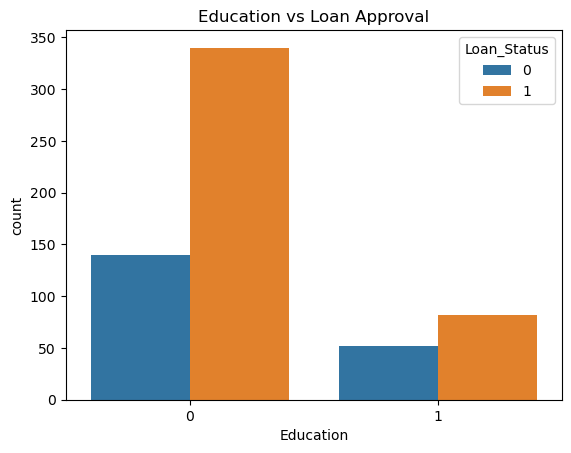

In [68]:
sns.countplot(
    x="Education",
    hue="Loan_Status",
    data=df
)
plt.title("Education vs Loan Approval")
plt.show()

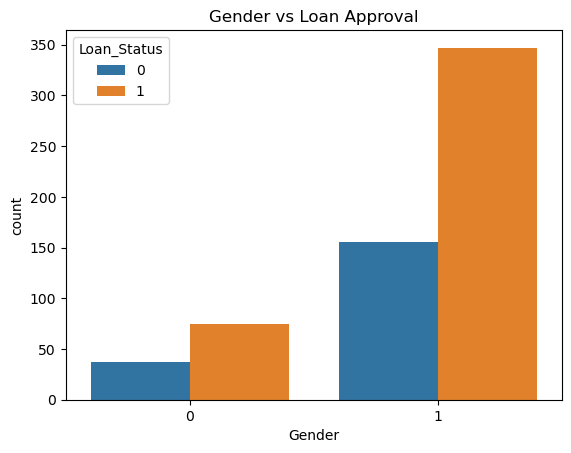

In [69]:
sns.countplot(
    x="Gender",
    hue="Loan_Status",
    data=df
)
plt.title("Gender vs Loan Approval")
plt.show()
    

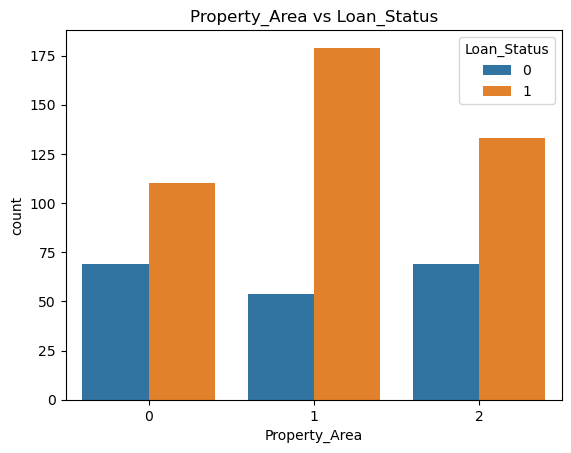

In [70]:
sns.countplot(
    x="Property_Area",
    hue="Loan_Status",
    data=df
)
plt.title("Property_Area vs Loan_Status")
plt.show()

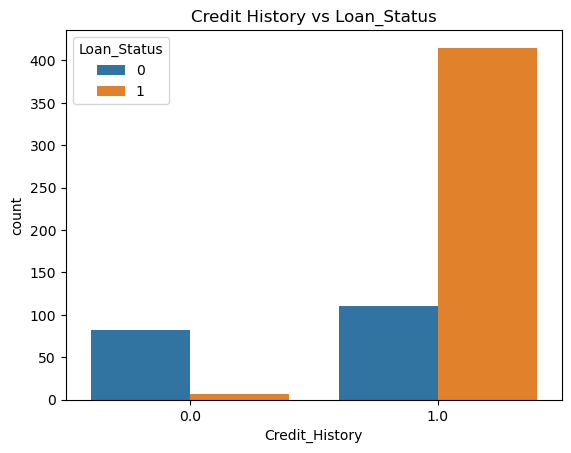

In [71]:
sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=df
)
plt.title("Credit History vs Loan_Status")
plt.show()
    

## Correlation Analysis

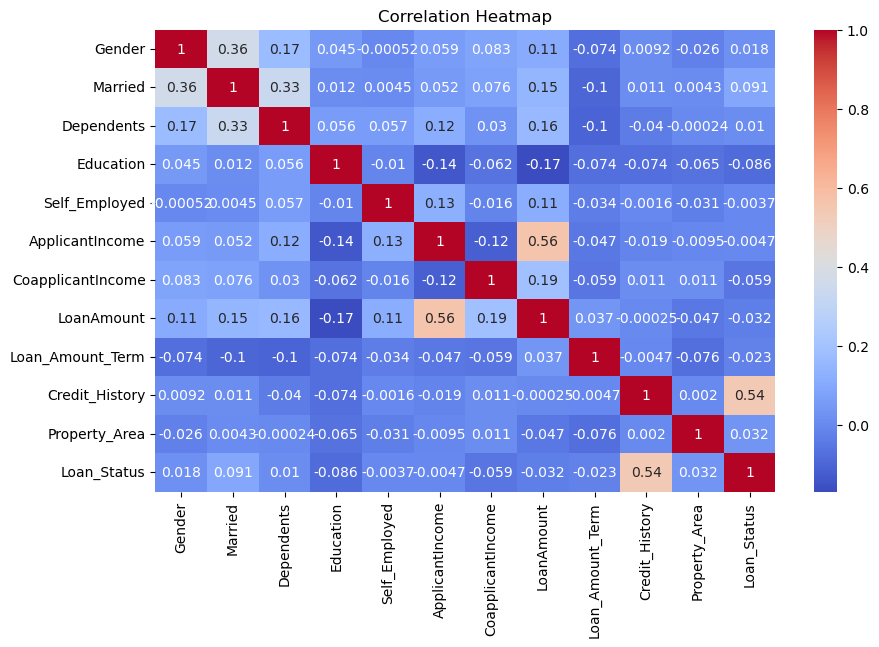

In [72]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

## Split training and testing data

In [73]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [74]:
print("Training_data",X_train.shape)
print("Testing_data",X_test.shape)

Training_data (491, 11)
Testing_data (123, 11)


## Model Building

In [85]:
model=LogisticRegression(max_iter=2000)

In [87]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore",category=ConvergenceWarning)

## Training the model

In [86]:
model.fit(X_train,y_train)
print("model trained successfully")

model trained successfully


C:\Users\Aditi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [81]:
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":abs(model.coef_[0])
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

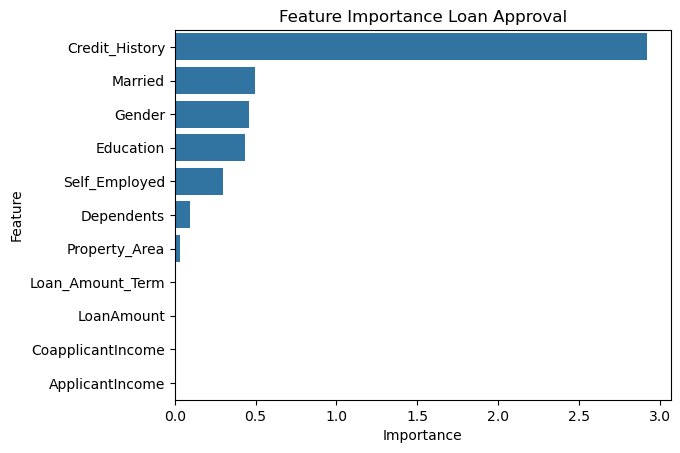

In [84]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)
plt.title("Feature Importance Loan Approval")
plt.show()

## Training accuracy

In [24]:
train_pred=model.predict(X_train)
train_accuracy=accuracy_score(
    y_train,
    train_pred
)
print("Training Accuracy:",
      round(train_accuracy*100,2),"%")

Training Accuracy: 79.84 %


## Testing accuracy

In [25]:
test_pred=model.predict(X_test)
test_accuracy=accuracy_score(
    y_test,
    test_pred
)
print("Testing_accuracy:",round(test_accuracy*100,2),"%")


Testing_accuracy: 86.18 %


## Evaluation metrics

In [27]:
precision=precision_score(
    y_test,
    test_pred
)
print("Precision:",
      round(precision,4))

Precision: 0.84


In [28]:
recall=recall_score(
    y_test,
    test_pred
)
print("Recall:",round(recall,4))

Recall: 0.9882


In [29]:
print("Classification Report")
print(classification_report(
    y_test,
    test_pred,
    target_names=["Rejected","Approved"]
))

Classification Report
              precision    recall  f1-score   support

    Rejected       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



Confusion Matrix:
[[22 16]
 [ 1 84]]


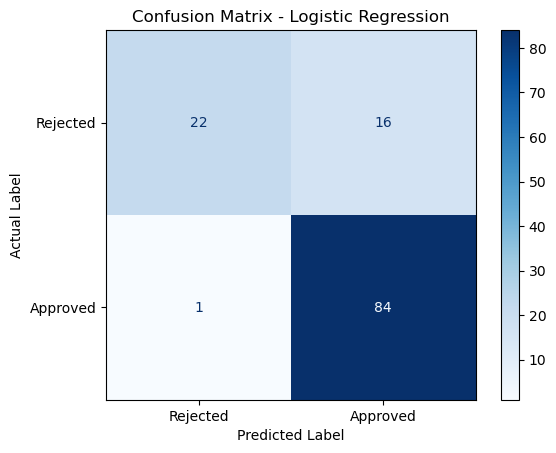

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, test_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Roc curve and Roc-Auc

ROC-AUC Score: 0.7889


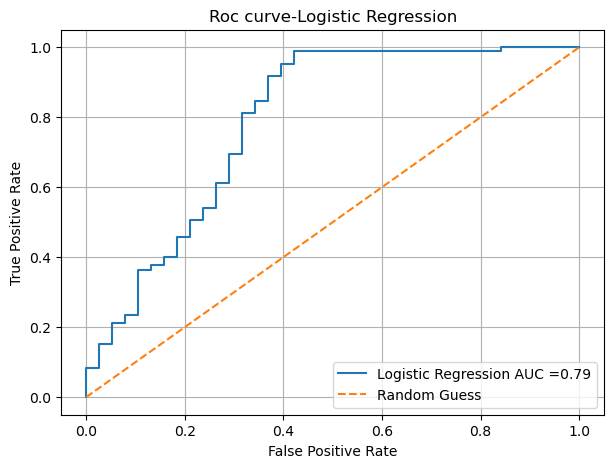

In [31]:
#Probability of Approved class
y_test_prob=model.predict_proba(X_test)[:,1]
#Roc values
fpr,tpr,thresholds=roc_curve(y_test,y_test_prob)
# AUC score
auc_score=roc_auc_score(y_test,y_test_prob)
print("ROC-AUC Score:",round(auc_score,4))
plt.figure(figsize=(7,5))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression AUC ={auc_score:.2f}"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Guess"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc curve-Logistic Regression")
plt.legend()
plt.grid()
plt.show()
    

## new predictions

In [34]:
import pandas as pd

# Take input from user
gender = input("Enter Gender (Male/Female): ").strip().title()
married = input("Enter Married (Yes/No): ").strip().title()
dependents = input("Enter Dependents (0/1/2/3+): ").strip()
education = input("Enter Education (Graduate/Not Graduate): ").strip()
self_employed = input("Enter Self Employed (Yes/No): ").strip().title()

applicant_income = float(input("Enter Applicant Income: "))
coapplicant_income = float(input("Enter Coapplicant Income: "))
loan_amount = float(input("Enter Loan Amount: "))
loan_amount_term = float(input("Enter Loan Amount Term: "))
credit_history = float(input("Enter Credit History (1/0): "))
property_area = input("Enter Property Area (Urban/Semiurban/Rural): ").strip().title()


# Create input DataFrame
input_data = pd.DataFrame({
    "Gender": [gender],
    "Married": [married],
    "Dependents": [dependents],
    "Education": [education],
    "Self_Employed": [self_employed],
    "ApplicantIncome": [applicant_income],
    "CoapplicantIncome": [coapplicant_income],
    "LoanAmount": [loan_amount],
    "Loan_Amount_Term": [loan_amount_term],
    "Credit_History": [credit_history],
    "Property_Area": [property_area]
})


# Convert categorical values
input_data["Gender"] = input_data["Gender"].map({
    "Male": 1,
    "Female": 0
})

input_data["Married"] = input_data["Married"].map({
    "Yes": 1,
    "No": 0
})

input_data["Dependents"] = input_data["Dependents"].map({
    "0": 0,
    "1": 1,
    "2": 2,
    "3+": 3
})

input_data["Education"] = input_data["Education"].map({
    "Graduate": 0,
    "Not Graduate": 1
})

input_data["Self_Employed"] = input_data["Self_Employed"].map({
    "Yes": 1,
    "No": 0
})

input_data["Property_Area"] = input_data["Property_Area"].map({
    "Urban": 2,
    "Semiurban": 1,
    "Rural": 0
})


# Check for missing values
if input_data.isnull().any().any():
    print("\nInvalid input detected.")
    print("Please enter values exactly as shown in the prompts.")
    print(input_data)
else:
    # Arrange columns in training order
    input_data = input_data[X_train.columns]

    # Make prediction
    prediction = model.predict(input_data)[0]

    print("\nPrediction:")

    if prediction == 1:
        print("Loan Approved")
    else:
        print("Loan Rejected")

Enter Gender (Male/Female):  Male
Enter Married (Yes/No):  Yes
Enter Dependents (0/1/2/3+):  0
Enter Education (Graduate/Not Graduate):  Graduate
Enter Self Employed (Yes/No):  Yes
Enter Applicant Income:  10000
Enter Coapplicant Income:  20000
Enter Loan Amount:  150000
Enter Loan Amount Term:  360
Enter Credit History (1/0):  1
Enter Property Area (Urban/Semiurban/Rural):  Urban



Prediction:
Loan Rejected


## model saving

In [29]:
import pickle
# save the trained Logistic Regression model
with open("loan_approval_model.pkl","wb") as file:
    pickle.dump(model,file)
print("Model saved successfully!")

Model saved successfully!


## EDA Insights Report

### 1. Dataset Overview
The dataset contains applicant information such as income, education, loan amount, credit history, and property area.
Data preprocessing was performed to handle missing values and convert categorical features into numerical format.

### 2. Univariate Analysis Insights
Loan approval distribution shows the number of approved and rejected applications.
Applicant income and loan amount distributions were analyzed to understand data patterns.
Boxplots were used to identify outliers in numerical features.

### 3. Categorical Feature Analysis
Education, Gender, Married status, and Property Area were analyzed against loan approval status.
Loan approval counts were compared across different categories.
Credit history showed a strong relationship with loan approval.

### 4. Correlation Analysis
Correlation analysis was performed to identify relationships between numerical features.
Features with higher correlation values were considered important for understanding the dataset.

### 5. Important Features Affecting Loan Approval
Feature importance analysis was performed using the machine learning model.
Credit History was identified as one of the most influential factors affecting loan approval prediction.
Other features such as income, education, and property area showed varying levels of contribution.

### 6. Key Findings
Applicants with better credit history have a higher probability of loan approval.
Loan approval is influenced by multiple factors rather than a single feature.
Categorical features provide useful insights into applicant groups.
Data visualization helped identify patterns, trends, and important relationships.

### 7. Conclusion

Exploratory Data Analysis helped understand the dataset structure, detect patterns, analyze relationships between features, and identify important factors influencing loan approval. These insights were useful for building a machine learning model for prediction.

